In [1]:
import pandas as pd

df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")
print(df.head())
print(df.info())

         Date  Year  Month  Rainfall_mm  Temperature_C  Humidity_%  \
0  01/01/1990  1990      1       120.96          31.67       81.78   
1  01/02/1990  1990      2       131.64          29.11       89.04   
2  01/03/1990  1990      3       147.77          23.70       75.82   
3  01/04/1990  1990      4       151.58          22.17       77.70   
4  01/05/1990  1990      5       112.19          19.58       66.47   

   Soil_Moisture  Extreme_Weather  Drought_Stress  Heat_Stress  Soybean_Yield  
0          78.26                0               0            1          48.30  
1          83.55                0               0            1          51.28  
2          92.58                0               0            0          54.99  
3          88.23                0               0            0          54.50  
4          80.27                0               0            0          49.85  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 11 colu

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")

# Convert the Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Set Date as the index and sort by date
df = df.set_index('Date').sort_index()

# Create a complete monthly date range
monthly_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='MS'  # Month Start frequency
)

# Reindex the dataset to enforce monthly continuity
df = df.reindex(monthly_index)
df.index.name = 'Date'

# Check for missing values created by reindexing
print("Missing values after enforcing monthly continuity:")
print(df.isnull().sum())

# Fill missing values if any exist
df = df.ffill()

# Verify the final time-indexed dataset
print("\nFirst 5 observations:")
print(df.head())

print("\nLast 5 observations:")
print(df.tail())

print("\nDataset Summary:")
print("Start Date:", df.index.min())
print("End Date:", df.index.max())
print("Total Monthly Observations:", len(df))
print("Inferred Frequency:", pd.infer_freq(df.index))

Missing values after enforcing monthly continuity:
Year               0
Month              0
Rainfall_mm        0
Temperature_C      0
Humidity_%         0
Soil_Moisture      0
Extreme_Weather    0
Drought_Stress     0
Heat_Stress        0
Soybean_Yield      0
dtype: int64

First 5 observations:
            Year  Month  Rainfall_mm  Temperature_C  Humidity_%  \
Date                                                              
1990-01-01  1990      1       120.96          31.67       81.78   
1990-02-01  1990      2       131.64          29.11       89.04   
1990-03-01  1990      3       147.77          23.70       75.82   
1990-04-01  1990      4       151.58          22.17       77.70   
1990-05-01  1990      5       112.19          19.58       66.47   

            Soil_Moisture  Extreme_Weather  Drought_Stress  Heat_Stress  \
Date                                                                      
1990-01-01          78.26                0               0            1   
1990-02-

In [3]:
import pandas as pd

# Load and prepare the dataset
df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")

# Convert Date to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date').sort_index()

# Enforce monthly continuity
monthly_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='MS'
)

df = df.reindex(monthly_index)
df.index.name = 'Date'

# Fill missing values if any
df = df.ffill()

# =====================================================
# 1. Short-term dynamics (t-1 and t-3)
# =====================================================

variables = [
    'Rainfall_mm',
    'Temperature_C',
    'Humidity_%',
    'Soil_Moisture',
    'Soybean_Yield'
]

for var in variables:
    df[f'{var}_lag1'] = df[var].shift(1)   # t-1
    df[f'{var}_lag3'] = df[var].shift(3)   # t-3

# =====================================================
# 2. Seasonal dynamics (t-12)
# =====================================================

for var in variables:
    df[f'{var}_lag12'] = df[var].shift(12)   # same month previous year

# =====================================================
# 3. Cross-variable lag relationships (Climate → Yield)
# =====================================================

climate_vars = [
    'Rainfall_mm',
    'Temperature_C',
    'Humidity_%',
    'Soil_Moisture',
    'Extreme_Weather',
    'Drought_Stress',
    'Heat_Stress'
]

for var in climate_vars:
    df[f'{var}_to_Yield_lag1'] = df[var].shift(1)
    df[f'{var}_to_Yield_lag3'] = df[var].shift(3)
    df[f'{var}_to_Yield_lag12'] = df[var].shift(12)

# =====================================================
# Remove rows with missing lag values
# =====================================================

df_features = df.dropna()

# =====================================================
# Display results
# =====================================================

print("Shape before lagging:", df.shape)
print("Shape after lagging:", df_features.shape)

print("\nNew temporal features created:")
new_features = [col for col in df_features.columns if 'lag' in col]
print(new_features)

print("\nFirst 5 rows of engineered dataset:")
print(df_features.head())

Shape before lagging: (420, 46)
Shape after lagging: (408, 46)

New temporal features created:
['Rainfall_mm_lag1', 'Rainfall_mm_lag3', 'Temperature_C_lag1', 'Temperature_C_lag3', 'Humidity_%_lag1', 'Humidity_%_lag3', 'Soil_Moisture_lag1', 'Soil_Moisture_lag3', 'Soybean_Yield_lag1', 'Soybean_Yield_lag3', 'Rainfall_mm_lag12', 'Temperature_C_lag12', 'Humidity_%_lag12', 'Soil_Moisture_lag12', 'Soybean_Yield_lag12', 'Rainfall_mm_to_Yield_lag1', 'Rainfall_mm_to_Yield_lag3', 'Rainfall_mm_to_Yield_lag12', 'Temperature_C_to_Yield_lag1', 'Temperature_C_to_Yield_lag3', 'Temperature_C_to_Yield_lag12', 'Humidity_%_to_Yield_lag1', 'Humidity_%_to_Yield_lag3', 'Humidity_%_to_Yield_lag12', 'Soil_Moisture_to_Yield_lag1', 'Soil_Moisture_to_Yield_lag3', 'Soil_Moisture_to_Yield_lag12', 'Extreme_Weather_to_Yield_lag1', 'Extreme_Weather_to_Yield_lag3', 'Extreme_Weather_to_Yield_lag12', 'Drought_Stress_to_Yield_lag1', 'Drought_Stress_to_Yield_lag3', 'Drought_Stress_to_Yield_lag12', 'Heat_Stress_to_Yield_lag1

In [4]:
import pandas as pd

# Load and prepare the dataset
df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")

# Convert Date to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date').sort_index()

# Enforce monthly continuity
monthly_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='MS'
)

df = df.reindex(monthly_index)
df.index.name = 'Date'

# Fill missing values if any
df = df.ffill()

# Variables of interest
variables = ['Rainfall_mm', 'Temperature_C', 'Soil_Moisture']

# =====================================================
# Rolling Statistical Features
# =====================================================

# Rolling windows (months)
windows = [3, 6, 12]

for var in variables:
    for window in windows:

        # Rolling mean
        df[f'{var}_roll_mean_{window}'] = (
            df[var]
            .rolling(window=window)
            .mean()
        )

        # Rolling standard deviation
        df[f'{var}_roll_std_{window}'] = (
            df[var]
            .rolling(window=window)
            .std()
        )

        # Rolling minimum
        df[f'{var}_roll_min_{window}'] = (
            df[var]
            .rolling(window=window)
            .min()
        )

        # Rolling maximum
        df[f'{var}_roll_max_{window}'] = (
            df[var]
            .rolling(window=window)
            .max()
        )

# =====================================================
# Expanding Statistical Features
# =====================================================

for var in variables:

    # Expanding mean
    df[f'{var}_exp_mean'] = (
        df[var]
        .expanding()
        .mean()
    )

    # Expanding standard deviation
    df[f'{var}_exp_std'] = (
        df[var]
        .expanding()
        .std()
    )

    # Expanding minimum
    df[f'{var}_exp_min'] = (
        df[var]
        .expanding()
        .min()
    )

    # Expanding maximum
    df[f'{var}_exp_max'] = (
        df[var]
        .expanding()
        .max()
    )

# Remove rows with missing values caused by rolling windows
df_features = df.dropna()

# =====================================================
# Results
# =====================================================

print("Original dataset shape:", df.shape)
print("Feature-engineered dataset shape:", df_features.shape)

# Display newly created features
new_features = [
    col for col in df_features.columns
    if ('roll' in col) or ('exp' in col)
]

print("\nNumber of rolling and expanding features created:",
      len(new_features))

print("\nSample of generated features:")
print(new_features[:15])

print("\nFirst 5 rows of engineered dataset:")
print(df_features.head())

Original dataset shape: (420, 58)
Feature-engineered dataset shape: (409, 58)

Number of rolling and expanding features created: 48

Sample of generated features:
['Rainfall_mm_roll_mean_3', 'Rainfall_mm_roll_std_3', 'Rainfall_mm_roll_min_3', 'Rainfall_mm_roll_max_3', 'Rainfall_mm_roll_mean_6', 'Rainfall_mm_roll_std_6', 'Rainfall_mm_roll_min_6', 'Rainfall_mm_roll_max_6', 'Rainfall_mm_roll_mean_12', 'Rainfall_mm_roll_std_12', 'Rainfall_mm_roll_min_12', 'Rainfall_mm_roll_max_12', 'Temperature_C_roll_mean_3', 'Temperature_C_roll_std_3', 'Temperature_C_roll_min_3']

First 5 rows of engineered dataset:
            Year  Month  Rainfall_mm  Temperature_C  Humidity_%  \
Date                                                              
1990-12-01  1990     12        84.41          27.55       71.26   
1991-01-01  1991      1       127.41          28.89       78.26   
1991-02-01  1991      2       119.85          27.88       92.13   
1991-03-01  1991      3       128.81          25.82       91

In [5]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")

# Convert Date
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date').sort_index()

# Month extraction
df['Month'] = df.index.month

# One-hot encoding
month_dummies = pd.get_dummies(df['Month'], prefix='Month')

# Cyclical encoding
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Merge one-hot features
df = pd.concat([df, month_dummies], axis=1)

print(df.head())

            Year  Month  Rainfall_mm  Temperature_C  Humidity_%  \
Date                                                              
1990-01-01  1990      1       120.96          31.67       81.78   
1990-02-01  1990      2       131.64          29.11       89.04   
1990-03-01  1990      3       147.77          23.70       75.82   
1990-04-01  1990      4       151.58          22.17       77.70   
1990-05-01  1990      5       112.19          19.58       66.47   

            Soil_Moisture  Extreme_Weather  Drought_Stress  Heat_Stress  \
Date                                                                      
1990-01-01          78.26                0               0            1   
1990-02-01          83.55                0               0            1   
1990-03-01          92.58                0               0            0   
1990-04-01          88.23                0               0            0   
1990-05-01          80.27                0               0            0   

    

In [6]:
# model development


Original Yield ADF Test
ADF Statistic: -3.864287823147824
p-value: 0.0023139680121295136

Differenced Yield ADF Test
ADF Statistic: -6.473323197599429
p-value: 1.3501681248876567e-08

ARIMA MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:          Soybean_Yield   No. Observations:                  420
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1429.579
Date:                Sat, 27 Jun 2026   AIC                           2865.158
Time:                        11:14:19   BIC                           2877.272
Sample:                    01-01-1990   HQIC                          2869.947
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1

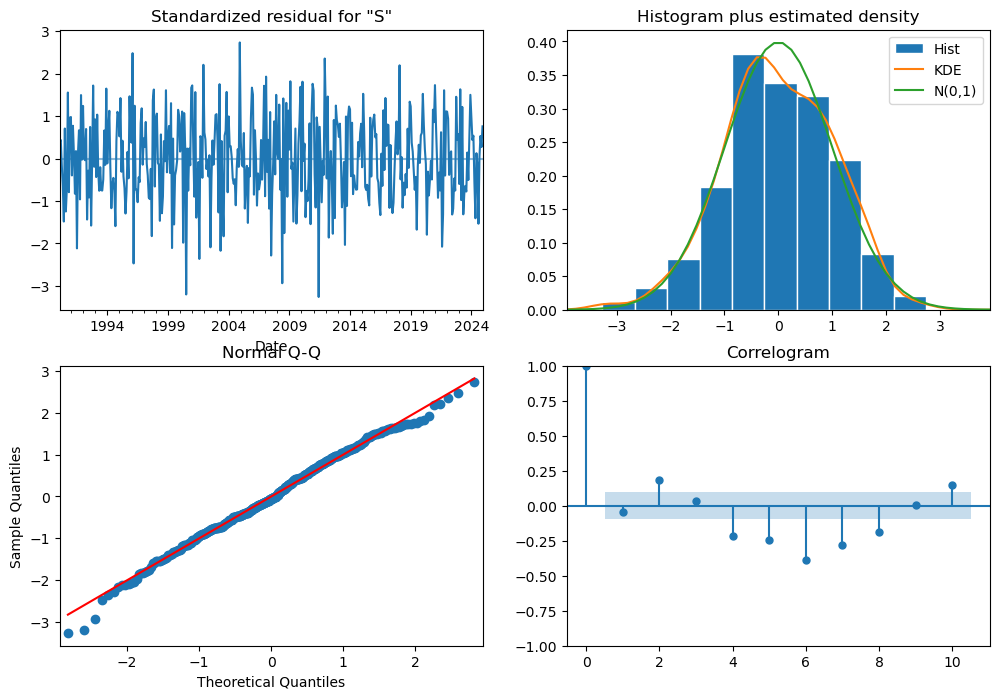


12-Month Forecast:
2025-01-01    41.448149
2025-02-01    41.939902
2025-03-01    42.164194
2025-04-01    42.266496
2025-05-01    42.313157
2025-06-01    42.334439
2025-07-01    42.344146
2025-08-01    42.348574
2025-09-01    42.350593
2025-10-01    42.351514
2025-11-01    42.351934
2025-12-01    42.352126
Freq: MS, Name: predicted_mean, dtype: float64


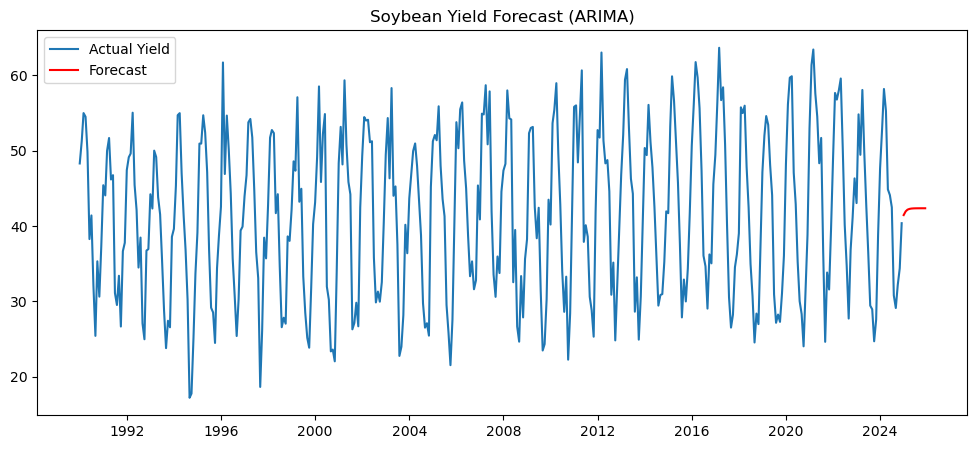

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# =====================================================
# 1. LOAD + TIME INDEXING
# =====================================================

df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date').sort_index()

# Enforce monthly continuity
df = df.asfreq('MS')

# Fill missing values
df = df.ffill()

# Target variable
y = df['Soybean_Yield']

# =====================================================
# 2. STATIONARITY TEST (ADF TEST)
# =====================================================

def adf_test(series, name="Series"):
    result = adfuller(series.dropna())
    print(f"\n{name} ADF Test")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

adf_test(y, "Original Yield")

# =====================================================
# 3. DIFFERENCING (MAKE STATIONARY IF NEEDED)
# =====================================================

y_diff = y.diff().dropna()
adf_test(y_diff, "Differenced Yield")

# If still non-stationary, you could use:
# y_diff = y.diff().diff().dropna()

# =====================================================
# 4. FIT ARIMA MODEL
# =====================================================

# (p,d,q) = (1,1,1) is a common starting point
model = ARIMA(y, order=(1,1,1))
model_fit = model.fit()

print("\nARIMA MODEL SUMMARY")
print(model_fit.summary())

# =====================================================
# 5. DIAGNOSTICS
# =====================================================

model_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

# =====================================================
# 6. FORECAST NEXT 12 MONTHS
# =====================================================

forecast = model_fit.forecast(steps=12)

print("\n12-Month Forecast:")
print(forecast)

# =====================================================
# 7. PLOT RESULTS
# =====================================================

plt.figure(figsize=(12,5))
plt.plot(y, label="Actual Yield")
plt.plot(forecast, label="Forecast", color="red")
plt.title("Soybean Yield Forecast (ARIMA)")
plt.legend()
plt.show()

C:\Users\Administrator\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:          Soybean_Yield   No. Observations:                  336
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -768.090
Date:                Sat, 27 Jun 2026   AIC                           1556.181
Time:                        11:14:21   BIC                           1594.262
Sample:                    01-01-1990   HQIC                          1571.366
                         - 12-01-2017                                         
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Rainfall_mm         0.1748      0.015     11.491      0.000       0.145       0.205
Temperature_C      -0.4678      0.059     -7.882      0.000      -0.584      -0.351
Humidity_%          0.1187      

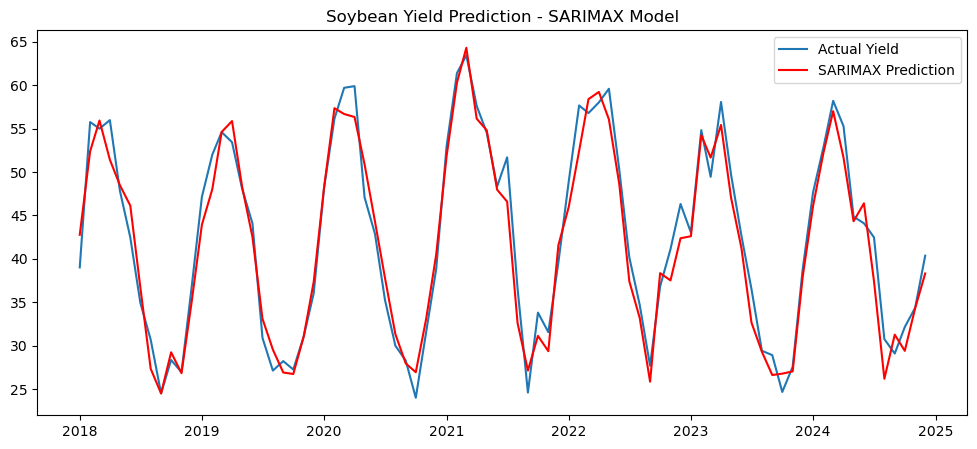

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================================
# 1. LOAD + TIME INDEX
# =====================================================

df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date').sort_index()

# enforce monthly continuity
df = df.asfreq('MS')
df = df.ffill()

# =====================================================
# 2. DEFINE TARGET + EXOG VARIABLES
# =====================================================

y = df['Soybean_Yield']

X = df[[
    'Rainfall_mm',
    'Temperature_C',
    'Humidity_%',
    'Soil_Moisture',
    'Extreme_Weather',
    'Drought_Stress',
    'Heat_Stress'
]]

# =====================================================
# 3. TRAIN-TEST SPLIT (80/20 TIME SPLIT)
# =====================================================

split = int(len(df) * 0.8)

y_train, y_test = y[:split], y[split:]
X_train, X_test = X[:split], X[split:]

# =====================================================
# 4. FIT SARIMAX MODEL
# =====================================================

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()

print(model_fit.summary())

# =====================================================
# 5. FORECAST
# =====================================================

forecast = model_fit.predict(
    start=len(y_train),
    end=len(y)-1,
    exog=X_test
)

# =====================================================
# 6. EVALUATION
# =====================================================

mae = mean_absolute_error(y_test, forecast)
rmse = np.sqrt(mean_squared_error(y_test, forecast))

print("\nMODEL PERFORMANCE")
print("MAE:", mae)
print("RMSE:", rmse)

# =====================================================
# 7. PLOT RESULTS
# =====================================================

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual Yield")
plt.plot(y_test.index, forecast, label="SARIMAX Prediction", color="red")
plt.title("Soybean Yield Prediction - SARIMAX Model")
plt.legend()
plt.show()

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================================
# 1. LOAD DATA
# =====================================================

df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date').sort_index()

df = df.asfreq('MS')
df = df.ffill()

# =====================================================
# 2. FEATURE ENGINEERING (IMPORTANT)
# =====================================================

# Lag features
for col in ['Rainfall_mm', 'Temperature_C', 'Humidity_%', 'Soil_Moisture']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag3'] = df[col].shift(3)
    df[f'{col}_lag12'] = df[col].shift(12)

# Rolling features
for col in ['Rainfall_mm', 'Temperature_C', 'Soil_Moisture']:
    df[f'{col}_roll3'] = df[col].rolling(3).mean()
    df[f'{col}_roll6'] = df[col].rolling(6).mean()

# Seasonality (cyclical encoding)
df['month'] = df.index.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Drop missing values created by lags/rolling
df = df.dropna()

# =====================================================
# 3. DEFINE FEATURES AND TARGET
# =====================================================

X = df.drop(columns=['Soybean_Yield'])
y = df['Soybean_Yield']

# =====================================================
# 4. TRAIN-TEST SPLIT (TIME SERIES STYLE)
# =====================================================

split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# =====================================================
# 5. STANDARDIZATION (VERY IMPORTANT FOR RIDGE/LASSO)
# =====================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================
# 6. RIDGE REGRESSION
# =====================================================

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

# =====================================================
# 7. LASSO REGRESSION
# =====================================================

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

# =====================================================
# 8. EVALUATION
# =====================================================

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{name} Results")
    print("MAE:", mae)
    print("RMSE:", rmse)

evaluate("Ridge Regression", y_test, ridge_pred)
evaluate("Lasso Regression", y_test, lasso_pred)

# =====================================================
# 9. FEATURE IMPORTANCE (LASSO)
# =====================================================

lasso_importance = pd.Series(lasso.coef_, index=X.columns)
print("\nTop Important Features (Lasso):")
print(lasso_importance.sort_values(ascending=False).head(10))


Ridge Regression Results
MAE: 1.9843830714072022
RMSE: 2.3833904071014342

Lasso Regression Results
MAE: 1.9423984004060104
RMSE: 2.3238133904132225

Top Important Features (Lasso):
Rainfall_mm            6.536914
Humidity_%             1.870737
Soil_Moisture          1.550282
Year                   1.252502
Soil_Moisture_roll6    0.556707
Soil_Moisture_lag12    0.320391
Temperature_C_lag3     0.207423
Temperature_C_roll6    0.165489
Rainfall_mm_lag12      0.156103
Humidity_%_lag12       0.068372
dtype: float64


In [10]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense

# =====================================================
# 1. LOAD + PREPROCESS
# =====================================================

df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date').sort_index()

df = df.asfreq('MS')
df = df.ffill()

# Features + target
X = df[['Rainfall_mm','Temperature_C','Humidity_%','Soil_Moisture']].values
y = df['Soybean_Yield'].values

# =====================================================
# 2. SCALING
# =====================================================

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# =====================================================
# 3. CREATE SEQUENCES
# =====================================================

def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

# Model A (short-term)
X1, y1 = create_sequences(X_scaled, y_scaled, window=2)

# Model B (seasonal)
X2, y2 = create_sequences(X_scaled, y_scaled, window=6)

# =====================================================
# 4. TRAIN-TEST SPLIT
# =====================================================

split1 = int(len(X1) * 0.8)
split2 = int(len(X2) * 0.8)

X1_train, X1_test = X1[:split1], X1[split1:]
y1_train, y1_test = y1[:split1], y1[split1:]

X2_train, X2_test = X2[:split2], X2[split2:]
y2_train, y2_test = y2[:split2], y2[split2:]

# =====================================================
# 5. MODEL A (kernel = 2)
# =====================================================

model_a = Sequential([
    Conv1D(64, kernel_size=2, activation='relu', input_shape=(2, X1.shape[2])),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

model_a.compile(optimizer='adam', loss='mse')

model_a.fit(X1_train, y1_train, epochs=20, batch_size=16, validation_split=0.2, verbose=1)

# =====================================================
# 6. MODEL B (kernel = 6)
# =====================================================

model_b = Sequential([
    Conv1D(64, kernel_size=6, activation='relu', input_shape=(6, X2.shape[2])),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

model_b.compile(optimizer='adam', loss='mse')

model_b.fit(X2_train, y2_train, epochs=20, batch_size=16, validation_split=0.2, verbose=1)

# =====================================================
# 7. PREDICTIONS
# =====================================================

pred_a = model_a.predict(X1_test)
pred_b = model_b.predict(X2_test)

# Inverse transform
pred_a = scaler_y.inverse_transform(pred_a)
y1_test_inv = scaler_y.inverse_transform(y1_test)

pred_b = scaler_y.inverse_transform(pred_b)
y2_test_inv = scaler_y.inverse_transform(y2_test)

# =====================================================
# 8. EVALUATION
# =====================================================

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)

evaluate("CNN Model A (kernel=2)", y1_test_inv, pred_a)
evaluate("CNN Model B (kernel=6)", y2_test_inv, pred_b)

C:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.1919 - val_loss: 0.0135
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0249 - val_loss: 0.0118
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0159 - val_loss: 0.0163
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0136 - val_loss: 0.0108
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0124 - val_loss: 0.0124
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0119 - val_loss: 0.0119
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0115 - val_loss: 0.0103
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0110 - val_loss: 0.0116
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0108 - val_loss: 0.0094
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0107 - val_loss: 0.0114
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0107 - val_loss: 0.0130
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0106 - va

In [11]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense

# =====================================================
# 1. LOAD + PREPROCESS
# =====================================================

df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date').sort_index()

df = df.asfreq('MS')
df = df.ffill()

# =====================================================
# 2. FEATURES + TARGET
# =====================================================

features = [
    'Rainfall_mm','Temperature_C','Humidity_%','Soil_Moisture',
    'Extreme_Weather','Drought_Stress','Heat_Stress'
]

y = df['Soybean_Yield']
X = df[features]

# =====================================================
# 3. SCALING (for deep learning)
# =====================================================

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(df[['Rainfall_mm','Temperature_C','Humidity_%','Soil_Moisture']])
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

# =====================================================
# 4. SEQUENCE CREATION (for CNN-LSTM)
# =====================================================

def create_sequences(X, y, window=6):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, window=6)

split = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# =====================================================
# 5. CNN + LSTM MODEL
# =====================================================

cnn_lstm = Sequential([
    Conv1D(64, kernel_size=2, activation='relu', input_shape=(6, X_seq.shape[2])),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])

cnn_lstm.compile(optimizer='adam', loss='mse')

cnn_lstm.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

cnn_pred = cnn_lstm.predict(X_test)
cnn_pred = scaler_y.inverse_transform(cnn_pred)
y_test_inv = scaler_y.inverse_transform(y_test)

# =====================================================
# 6. SARIMAX MODEL
# =====================================================

sarimax_model = SARIMAX(y, exog=X, order=(1,1,1))
sarimax_fit = sarimax_model.fit(disp=False)

sarimax_pred = sarimax_fit.predict(start=1, end=len(y)-1, exog=X.iloc[1:])

# Align with test set
test_size = int(len(y) * 0.2)
sarimax_test = sarimax_pred[-test_size:]
y_test_sarimax = y[-test_size:]

# =====================================================
# 7. RANDOM FOREST MODEL
# =====================================================

X_train_ml = X.iloc[:len(y)-test_size]
X_test_ml = X.iloc[len(y)-test_size:]
y_train_ml = y.iloc[:len(y)-test_size]
y_test_ml = y.iloc[len(y)-test_size:]

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_ml, y_train_ml)

rf_pred = rf.predict(X_test_ml)

# =====================================================
# 8. ENSEMBLE MODEL
# =====================================================

ensemble_pred = (sarimax_test.values + rf_pred) / 2

# =====================================================
# 9. EVALUATION FUNCTION
# =====================================================

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)

# =====================================================
# 10. RESULTS
# =====================================================

evaluate("CNN-LSTM Hybrid", y_test_inv, cnn_pred)
evaluate("SARIMAX Model", y_test_sarimax, sarimax_test.values)
evaluate("Random Forest", y_test_ml, rf_pred)
evaluate("SARIMAX + RF Ensemble", y_test_ml, ensemble_pred)

C:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000246BE8418A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


C:\Users\Administrator\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



CNN-LSTM Hybrid
MAE: 3.70185593938253
RMSE: 4.771766848886374

SARIMAX Model
MAE: 1.9017071182907606
RMSE: 2.306993020077066

Random Forest
MAE: 2.66861607142857
RMSE: 3.3338103140623954

SARIMAX + RF Ensemble
MAE: 2.133484952110687
RMSE: 2.6269800372239276


In [12]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# =====================================================
# 1. LOAD DATA
# =====================================================

df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date').sort_index()

df = df.asfreq('MS')
df = df.ffill()

# =====================================================
# 2. FEATURES + TARGET
# =====================================================

X = df[['Rainfall_mm','Temperature_C','Humidity_%','Soil_Moisture']].values
y = df['Soybean_Yield'].values

# =====================================================
# 3. SCALING
# =====================================================

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# =====================================================
# 4. CREATE 12-MONTH SEQUENCES
# =====================================================

def create_sequences(X, y, window=12):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, window=12)

# =====================================================
# 5. TRAIN-TEST SPLIT
# =====================================================

split = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# =====================================================
# 6. GRU MODEL
# =====================================================

model = Sequential([
    GRU(64, activation='tanh', return_sequences=False, input_shape=(12, X_seq.shape[2])),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# =====================================================
# 7. PREDICTIONS
# =====================================================

pred = model.predict(X_test)

# inverse scaling
pred = scaler_y.inverse_transform(pred)
y_test_inv = scaler_y.inverse_transform(y_test)

# =====================================================
# 8. EVALUATION
# =====================================================

mae = mean_absolute_error(y_test_inv, pred)
rmse = np.sqrt(mean_squared_error(y_test_inv, pred))

print("\nGRU Model Results (12-month window)")
print("MAE:", mae)
print("RMSE:", rmse)

Epoch 1/30


C:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0548 - val_loss: 0.0153
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0148 - val_loss: 0.0090
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0110 - val_loss: 0.0115
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0109 - val_loss: 0.0079
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0105 - val_loss: 0.0091
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0103 - val_loss: 0.0088
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0102 - val_loss: 0.0076
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0102 - val_loss: 0.0084
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0116 - val_loss: 0.0106
Epoch 10/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0106 - val_loss: 0.0097
Epoch 11/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0099 - val_loss: 0.0082
Epoch 12/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0104 - val_l

In [13]:
import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# =====================================================
# 1. LOAD DATA
# =====================================================

df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date').sort_index()
df = df.asfreq('MS')
df = df.ffill()

y = df['Soybean_Yield']

# =====================================================
# 2. ARIMA MODEL
# =====================================================

arima_model = ARIMA(y, order=(1,1,1))
arima_fit = arima_model.fit()

arima_pred = arima_fit.predict(start=1, end=len(y)-1)

# =====================================================
# 3. RESIDUALS
# =====================================================

residuals = y[1:] - arima_pred[1:]

# =====================================================
# 4. SCALE RESIDUALS
# =====================================================

scaler = MinMaxScaler()
residuals_scaled = scaler.fit_transform(residuals.values.reshape(-1,1))

# =====================================================
# 5. CREATE SEQUENCES FOR GRU
# =====================================================

def create_sequences(data, window=12):
    X, y_seq = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y_seq.append(data[i+window])
    return np.array(X), np.array(y_seq)

X_seq, y_seq = create_sequences(residuals_scaled, window=12)

# =====================================================
# 6. TRAIN-TEST SPLIT
# =====================================================

split = int(len(X_seq)*0.8)

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# =====================================================
# 7. GRU MODEL ON RESIDUALS
# =====================================================

model = Sequential([
    GRU(64, activation='tanh', input_shape=(12,1)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=25, batch_size=16, verbose=1)

# =====================================================
# 8. PREDICT RESIDUALS
# =====================================================

residual_pred = model.predict(X_test)
residual_pred = scaler.inverse_transform(residual_pred)

# =====================================================
# 9. FINAL HYBRID PREDICTION
# =====================================================

arima_final = arima_pred[-len(residual_pred):].values

final_pred = arima_final + residual_pred.flatten()

actual = y[-len(final_pred):]

# =====================================================
# 10. EVALUATION
# =====================================================

mae = mean_absolute_error(actual, final_pred)
rmse = np.sqrt(mean_squared_error(actual, final_pred))

print("\nARIMA + GRU Hybrid Results")
print("MAE:", mae)
print("RMSE:", rmse)

Epoch 1/25


C:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1993
Epoch 2/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2965
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2745
Epoch 4/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2536
Epoch 5/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2345
Epoch 6/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2168
Epoch 7/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2003
Epoch 8/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1850
Epoch 9/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1709
Epoch 10/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1578
Epoch 11/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1456
Epoch 12/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1344
Epoch 13/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1241
Epoch 14/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1148
Epoch 15/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1061
Epoch 16/25
21/21 ━━━━━━━━━━━━

In [14]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GRU, Dense

# =====================================================
# 1. LOAD DATA
# =====================================================

df = pd.read_csv(r"data/raw/soybean_climate_large_test_dataset.csv")

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date').sort_index()
df = df.asfreq('MS')
df = df.ffill()

X = df[['Rainfall_mm','Temperature_C','Humidity_%','Soil_Moisture']].values
y = df['Soybean_Yield'].values

# =====================================================
# 2. SCALING
# =====================================================

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# =====================================================
# 3. SEQUENCES (12-month window)
# =====================================================

def create_sequences(X, y, window=12):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, window=12)

split = int(len(X_seq)*0.8)

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# =====================================================
# 4. CNN + GRU MODEL
# =====================================================

model = Sequential([
    Conv1D(64, kernel_size=2, activation='relu', input_shape=(12, X_seq.shape[2])),
    GRU(64, activation='tanh'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=30, batch_size=16, verbose=1)

# =====================================================
# 5. PREDICTIONS
# =====================================================

pred = model.predict(X_test)

pred = scaler_y.inverse_transform(pred)
y_test_inv = scaler_y.inverse_transform(y_test)

# =====================================================
# 6. EVALUATION
# =====================================================

mae = mean_absolute_error(y_test_inv, pred)
rmse = np.sqrt(mean_squared_error(y_test_inv, pred))

print("\nCNN + GRU Hybrid Results")
print("MAE:", mae)
print("RMSE:", rmse)

Epoch 1/30


C:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0787
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0174
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0107
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0098
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0096
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0093
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0093
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0099
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0090
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0091
Epoch 11/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0097
Epoch 12/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0092
Epoch 13/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0086
Epoch 14/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0090
Epoch 15/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0089
Epoch 16/30
21/21 ━━━━━━━━━━━━

In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================
# Evaluation Function
# =====================================================

def evaluate_model(name, y_true, y_pred):

    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # Make lengths equal if necessary
    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-"*40)
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")

    return [name, mae, mse, rmse, r2]


results = []

# =====================================================
# SARIMAX
# =====================================================

if 'sarimax_pred' in globals() and 'y_test_sarimax' in globals():

    sarimax_pred_test = np.array(sarimax_pred).flatten()[-len(y_test_sarimax):]

    results.append(
        evaluate_model(
            "SARIMAX",
            y_test_sarimax,
            sarimax_pred_test
        )
    )

# =====================================================
# RANDOM FOREST
# =====================================================

if 'rf_pred' in globals() and 'y_test_ml' in globals():

    results.append(
        evaluate_model(
            "Random Forest",
            y_test_ml,
            rf_pred
        )
    )

# =====================================================
# GRU
# =====================================================

if 'gru_pred' in globals():

    print("\nGRU prediction found.")
    print("Please replace y_test_gru below with the correct GRU target if needed.")

# =====================================================
# CNN-GRU
# =====================================================

if 'cnn_gru_pred' in globals():

    print("CNN-GRU prediction found.")
    print("Replace y_test_cnn_gru with the correct target.")

# =====================================================
# CNN-LSTM
# =====================================================

if 'cnn_lstm_pred' in globals():

    print("CNN-LSTM prediction found.")
    print("Replace y_test_cnn_lstm with the correct target.")

# =====================================================
# ARIMA-GRU
# =====================================================

if 'arima_gru_pred' in globals():

    print("ARIMA-GRU prediction found.")
    print("Replace y_test_arima_gru with the correct target.")

# =====================================================
# Final Table
# =====================================================

if len(results) > 0:

    results_df = pd.DataFrame(
        results,
        columns=["Model","MAE","MSE","RMSE","R2"]
    )

    results_df = results_df.sort_values("RMSE")

    print("\n")
    print(results_df)

    results_df.to_csv("model_comparison_results.csv",index=False)


SARIMAX
----------------------------------------
MAE : 1.9017
MSE : 5.3222
RMSE: 2.3070
R²  : 0.9574

Random Forest
----------------------------------------
MAE : 2.6686
MSE : 11.1143
RMSE: 3.3338
R²  : 0.9110


           Model       MAE        MSE      RMSE        R2
0        SARIMAX  1.901707   5.322217  2.306993  0.957402
1  Random Forest  2.668616  11.114291  3.333810  0.911043


In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ======================================================
# Evaluation Function
# ======================================================

def evaluate_model(name, y_true, y_pred):

    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    # Match lengths automatically
    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return [name, mae, mse, rmse, r2]


results = []

# ======================================================
# SARIMAX
# ======================================================

results.append(
    evaluate_model(
        "SARIMAX",
        y_test_sarimax,
        sarimax_pred_test
    )
)

# ======================================================
# Random Forest
# ======================================================

results.append(
    evaluate_model(
        "Random Forest",
        y_test_ml,
        rf_pred
    )
)

# ======================================================
# Ridge
# ======================================================

results.append(
    evaluate_model(
        "Ridge",
        y_test_ml,
        ridge_pred
    )
)

# ======================================================
# Lasso
# ======================================================

results.append(
    evaluate_model(
        "Lasso",
        y_test_ml,
        lasso_pred
    )
)

# ======================================================
# GRU
# ======================================================

results.append(
    evaluate_model(
        "GRU",
        y_test_inv,
        pred
    )
)

# ======================================================
# CNN
# ======================================================

results.append(
    evaluate_model(
        "CNN",
        y_test_inv,
        cnn_pred
    )
)

# ======================================================
# CNN-GRU (if final_pred is CNN-GRU)
# ======================================================

results.append(
    evaluate_model(
        "CNN-GRU",
        y_test_inv,
        final_pred
    )
)

# ======================================================
# Results Table
# ======================================================

results_df = pd.DataFrame(
    results,
    columns=["Model","MAE","MSE","RMSE","R²"]
)

results_df = results_df.sort_values("RMSE")

print(results_df)

results_df.to_csv("Model_Comparison.csv", index=False)

           Model       MAE         MSE       RMSE        R²
0        SARIMAX  1.901707    5.322217   2.306993  0.957402
1  Random Forest  2.668616   11.114291   3.333810  0.911043
4            GRU  3.245447   17.304502   4.159868  0.862319
5            CNN  5.955779   48.477571   6.962584  0.614293
6        CNN-GRU  7.350789   81.273712   9.015193  0.353354
2          Ridge  9.501811  125.721428  11.212557  0.010938
3          Lasso  9.516283  125.900444  11.220537  0.009530
